# Ejercicio 5: Espacio Vectorial

## Objetivo de la práctica
- Implementar un Sistema de Recuperación de Información completo, desde la lectura del corpus hasta la recuperación de resultados.

## Parte 0: Carga del Corpus

Vamos a utilizar la API de Kaggle para acceder al dataset _Wikipedia Text Corpus for NLP and LLM Projects_

El corpus está disponible desde este [link](https://www.kaggle.com/datasets/gzdekzlkaya/wikipedia-text-corpus-for-nlp-and-llm-projects?utm_source=chatgpt.com)

### Actividad

1. Carga el corpus
2. Realiza las etapas de preprocesamiento sobre el corpus


In [2]:
!pip install kagglehub

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\luis3\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import re
import string
import nltk
import kagglehub

# Descargar el dataset de Kaggle
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from nltk.corpus import stopwords as nltk_sw

C:\Users\luis3\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Importar el dataset de Kaggle
path = kagglehub.dataset_download(
    "gzdekzlkaya/wikipedia-text-corpus-for-nlp-and-llm-projects"
)

print("Dataset descargado en:", path)

100%|██████████| 18.7M/18.7M [02:09<00:00, 151kB/s] 

Extracting files...


Dataset descargado en: C:\Users\luis3\.cache\kagglehub\datasets\gzdekzlkaya\wikipedia-text-corpus-for-nlp-and-llm-projects\versions\1


['wikipedia_text_corpus.csv']


In [8]:
import os
# cargar archivo
files = os.listdir(path)
print(files)
csv_file = os.path.join(path, files[0])
df = pd.read_csv(csv_file)
df.head()


,Unnamed: 0,text
0,1,Anovo\n\nAnovo (formerly A Novo) is a computer...
1,2,Battery indicator\n\nA battery indicator (also...
2,3,"Bob Pease\n\nRobert Allen Pease (August 22, 19..."
3,4,CAVNET\n\nCAVNET was a secure military forum w...
4,5,CLidar\n\nThe CLidar is a scientific instrumen...


## Parte 1: Recuperación con TF-IDF

### Actividad:
3. Obtén la representación vectorial de los documentos utilizando el modelo TF-IDF
4. A partir de un conjunto de 10 queries, verifica la recuperación del sistema

In [13]:
import nltk
# importar stopwords y tokenizador
nltk.download('punkt')
nltk.download('stopwords')
# Crear un conjunto de stopwords
stop_words = set(stopwords.words('english'))

# Función de preprocesamiento de texto
def preprocess_text(text):
    
    # Convertir a minúsculas
    text = text.lower()   
    # Eliminar números
    text = re.sub(r'\d+', '', text)
    # Eliminar puntuación
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Tokenización
    tokens = word_tokenize(text)
    # Eliminar stopwords
    tokens = [word for word in tokens if word not in stop_words]
    
    return " ".join(tokens)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\luis3\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\luis3\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [16]:
nltk.download('punkt_tab')
# Aplicar preprocesamiento al texto del DataFrame
df['processed_text'] = df['text'].astype(str).apply(preprocess_text)
# Mostrar las primeras filas del DataFrame con .head()
df[['text', 'processed_text']].head()

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\luis3\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


,text,processed_text
0,Anovo\n\nAnovo (formerly A Novo) is a computer...,anovo anovo formerly novo computer services co...
1,Battery indicator\n\nA battery indicator (also...,battery indicator battery indicator also known...
2,"Bob Pease\n\nRobert Allen Pease (August 22, 19...",bob pease robert allen pease august â â€ “ jun...
3,CAVNET\n\nCAVNET was a secure military forum w...,cavnet cavnet secure military forum became ope...
4,CLidar\n\nThe CLidar is a scientific instrumen...,clidar clidar scientific instrument used measu...


In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# --- TF: frecuencia de términos (conteos crudos) ---
count_vectorizer = CountVectorizer(
    stop_words='english',
    max_features=20000
)
# Ajustar y transformar el corpus para obtener la matriz TF
matriz_tf = count_vectorizer.fit_transform(df['processed_text'])
vocabulario = count_vectorizer.get_feature_names_out()
# Crear un DataFrame para visualizar la matriz TF
df_tf = pd.DataFrame(
    matriz_tf.toarray(),
    index=df.index,
    columns=vocabulario
)

print('Matriz TF (frecuencia de términos):')
print(f'Dimensiones: {df_tf.shape}')
df_tf.head()

Matriz TF (frecuencia de términos):
Dimensiones: (10859, 20000)


,aa,aaa,aachen,aaf,aakash,aaron,ab,aba,abacus,abandon,...,â½,âˆ,ãƒ,î²,î¼m,î¼s,ïƒ,œa,œthe,šà
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [18]:
# --- DF: Document Frequency (en cuántos documentos aparece cada término) ---
df_freq = (matriz_tf.toarray() > 0).sum(axis=0)
# Crear un Series para visualizar los términos más comunes por DF
df_df = pd.Series(df_freq, index=vocabulario).sort_values(ascending=False)

print('Top 20 términos por Document Frequency (DF):')
print(df_df.head(20))

Top 20 términos por Document Frequency (DF):
used           6279
use            4774
using          3845
new            3787
time           3699
including      3369
technology     3229
systems        3152
known          3137
include        3074
based          3042
called         3009
different      2907
high           2899
developed      2736
company        2734
number         2675
development    2659
large          2559
design         2555
dtype: int64


In [19]:
# --- IDF: Inverse Document Frequency ---
N = len(df['processed_text'])  # número total de documentos
idf_valores = np.log((N + 1) / (df_freq + 1)) + 1  # fórmula sklearn
# Crear un Series para visualizar los términos con mayor IDF (más raros/específicos)
df_idf = pd.Series(idf_valores, index=vocabulario).sort_values(ascending=False)

print('Top 20 términos con mayor IDF (más raros/específicos):')
print(df_idf.head(20))

Top 20 términos con mayor IDF (más raros/específicos):
napolis          9.599694
transferjet      9.599694
navtex           9.599694
netduino         9.599694
neuralyzer       9.599694
nfv              9.599694
clc              9.599694
transsiberian    9.599694
cnav             9.599694
efvs             9.599694
xts              9.599694
eichholz         9.599694
eidr             9.599694
ecomobility      9.599694
yaba             9.599694
yiannopoulos     9.599694
edrs             9.599694
enerpos          9.599694
epanet           9.599694
episerver        9.599694
dtype: float64


In [32]:
# --- TF-IDF con sklearn ---
tfidf_vectorizer = TfidfVectorizer(
    #stop_words='english',
    max_features=20000,
    sublinear_tf=True
)
# Ajustar y transformar el corpus para obtener la matriz TF-IDF
matriz_tfidf = tfidf_vectorizer.fit_transform(df['processed_text'])
# Obtener el vocabulario de TF-IDF
vocab_tfidf  = tfidf_vectorizer.get_feature_names_out()
# Crear un DataFrame para visualizar la matriz TF-IDF
df_tfidf = pd.DataFrame(
    matriz_tfidf.toarray(),
    index=df.index,
    columns=vocab_tfidf
)

print('Matriz TF-IDF:')
print(f'Dimensiones: {df_tfidf.shape}')
df_tfidf.head()

Matriz TF-IDF:
Dimensiones: (10859, 20000)


,aa,aaa,aachen,aaf,aakash,aaron,ab,aba,abacus,abandon,...,â½,âˆ,ãƒ,î²,î¼m,î¼s,ïƒ,œa,œthe,šà
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [22]:
# Definir queries de ejemplo
queries = [
    "artificial intelligence",
    "machine learning",
    "history of europe",
    "world war",
    "computer science",
    "data analysis",
    "neural networks",
    "space exploration",
    "human biology",
    "climate change"
]

In [23]:
from sklearn.metrics.pairwise import cosine_similarity

# Función de búsqueda usando TF-IDF y similitud coseno
def search_tfidf(query, top_k=5):
    
    query = preprocess_text(query)
    # Transformar la query a vector TF-IDF
    query_vector = tfidf_vectorizer.transform([query])
    # Calcular similitud coseno entre la query y los documentos
    similarities = cosine_similarity(query_vector, matriz_tfidf).flatten()
    # Obtener los índices de los documentos más similares
    top_indices = similarities.argsort()[-top_k:][::-1]
    
    results = []
    # Construir los resultados con el índice del documento, 
    # la puntuación de similitud y un fragmento del texto original
    for idx in top_indices:
        results.append({
            'document_index': idx,
            'score': similarities[idx],
            'text': df.iloc[idx]['text'][:300]
        })
    
    return results

In [39]:
for query in queries:
    print(f"\nQUERY: {query}")
    print("-" * 50)

    results = search_tfidf(query, top_k=5)
    for r in results:
        print(f"Doc {r['document_index']} | Score: {r['score']:.4f}")



QUERY: artificial intelligence
--------------------------------------------------
Doc 5229 | Score: 0.3618
Doc 8176 | Score: 0.3285
Doc 3905 | Score: 0.3035
Doc 8600 | Score: 0.2468
Doc 10838 | Score: 0.2372

QUERY: machine learning
--------------------------------------------------
Doc 10547 | Score: 0.4272
Doc 7900 | Score: 0.3178
Doc 4733 | Score: 0.3040
Doc 51 | Score: 0.2938
Doc 7023 | Score: 0.2562

QUERY: history of europe
--------------------------------------------------
Doc 4850 | Score: 0.2061
Doc 504 | Score: 0.1981
Doc 2907 | Score: 0.1952
Doc 3981 | Score: 0.1952
Doc 1534 | Score: 0.1827

QUERY: world war
--------------------------------------------------
Doc 915 | Score: 0.4198
Doc 3481 | Score: 0.3655
Doc 8313 | Score: 0.2670
Doc 9265 | Score: 0.2627
Doc 1257 | Score: 0.2267

QUERY: computer science
--------------------------------------------------
Doc 9852 | Score: 0.3674
Doc 120 | Score: 0.3229
Doc 3842 | Score: 0.2793
Doc 8656 | Score: 0.2541
Doc 6569 | Score: 0.23

## Parte 2: Recuperación con BM25

### Actividad:
5. Implementa un sistema de recuperación usando el modelo BM25.
6. Para el mismo conjunto de 10 queries, verifica la recuperación del sistema

In [28]:
# --- Tokenización personalizada (sin sklearn) ---
# preprocesamiento básico + tokenización manual + eliminación de stopwords
def tokenizar(texto):
    # Convertir a minúsculas
    texto = texto.lower()
    # Eliminar números
    tokens = re.findall(r'\b[a-z]+\b', texto)
    # Eliminar stopwords
    stop = set(nltk_sw.words('english'))  # ~180 stopwords automáticas
    return [t for t in tokens if t not in stop and len(t) > 2]
# Tokenizar todo el corpus
# 
docs_tokens = [tokenizar(doc) for doc in df['processed_text']]
print(f'Tokenización lista. Ejemplo (primeros 10 tokens del doc 0):')
print(docs_tokens[0][:10])

Tokenización lista. Ejemplo (primeros 10 tokens del doc 0):
['anovo', 'anovo', 'formerly', 'novo', 'computer', 'services', 'company', 'based', 'beauvais', 'france']


In [29]:
# Paso 2: Longitudes de documentos y promedio
# Calcular la longitud de cada documento (número de tokens)
doc_lengths = [len(tokens) for tokens in docs_tokens]
# Calcular la longitud promedio de los documentos
avgdl = sum(doc_lengths) / len(doc_lengths)

# Mostrar estadísticas de longitud de documentos
print(f'Longitud promedio de documentos: {avgdl:.0f} tokens')
print(f'Doc más corto: {min(doc_lengths)} tokens')
print(f'Doc más largo: {max(doc_lengths)} tokens')

Longitud promedio de documentos: 437 tokens
Doc más corto: 1 tokens
Doc más largo: 19400 tokens


In [30]:
# Paso 3: TF por documento (conteo de cada término)
from typing import Counter
# Crear un Counter para cada documento con 
# la frecuencia de cada término
tf_docs = [Counter(tokens) for tokens in docs_tokens]
# Mostrar los términos más comunes del primer documento
print('TF del documento 0 (top 10 palabras):')
print(tf_docs[0].most_common(10))

TF del documento 0 (top 10 palabras):
[('anovo', 2), ('company', 2), ('formerly', 1), ('novo', 1), ('computer', 1), ('services', 1), ('based', 1), ('beauvais', 1), ('france', 1), ('founded', 1)]


In [31]:
# Paso 4: DF e IDF de BM25
import math

N = len(df ['processed_text'])  # número total de documentos

# DF: en cuántos documentos aparece cada término
df_bm25 = Counter()
for tf in tf_docs:
    for term in tf:
        df_bm25[term] += 1

# IDF de BM25: log((N - df + 0.5) / (df + 0.5) + 1)
def idf_bm25(term):
    df = df_bm25.get(term, 0)
    return math.log((N - df + 0.5) / (df + 0.5) + 1)

print('DF e IDF BM25 calculados')
print(f"IDF de 'murder': {idf_bm25('murder'):.4f}")
print(f"IDF de 'said'  : {idf_bm25('said'):.4f}")

DF e IDF BM25 calculados
IDF de 'murder': 5.9085
IDF de 'said'  : 2.6589


In [33]:
# --- Paso 5: Parámetros BM25 ---
k1 = 1.5   # controla la saturación de TF (típico: 1.2 - 2.0)
b  = 0.75  # controla la normalización por longitud (típico: 0.75)

print(f'Parámetros BM25: k1={k1}, b={b}')

# --- Paso 6: Score BM25 para un documento ---
def score_bm25_doc(query_terms, doc_idx):
    score = 0
    tf = tf_docs[doc_idx]
    dl = doc_lengths[doc_idx]
    for term in query_terms:
        if term not in tf:
            continue
        tf_term = tf[term]
        idf = idf_bm25(term)
        numerador   = tf_term * (k1 + 1)
        denominador = tf_term + k1 * (1 - b + b * dl / avgdl)
        score += idf * (numerador / denominador)
    return score

Parámetros BM25: k1=1.5, b=0.75


In [35]:
# --- Paso 7: Score BM25 para todos los documentos ---
def buscar_bm25(consulta, top_n=10):
    # Tokenizar la consulta
    query_terms = tokenizar(consulta)
    scores = [
        (i, score_bm25_doc(query_terms, i))
        for i in range(len(df['processed_text']))
    ]
    scores.sort(key=lambda x: x[1], reverse=True)
    return scores[:top_n]

In [40]:
for query in queries:
    print(f"\nQUERY: {query}")
    print("-" * 80)
    
    results = buscar_bm25(query, top_n=5)
    for i, (idx, score) in enumerate(results, 1):
        print(f"{i}. Doc {idx} | Score: {score:.4f}")



QUERY: artificial intelligence
--------------------------------------------------------------------------------
1. Doc 5229 | Score: 15.2780
2. Doc 8176 | Score: 14.6589
3. Doc 669 | Score: 14.4272
4. Doc 485 | Score: 13.9636
5. Doc 10838 | Score: 13.9127

QUERY: machine learning
--------------------------------------------------------------------------------
1. Doc 10547 | Score: 13.8340
2. Doc 4733 | Score: 12.8368
3. Doc 10699 | Score: 12.5900
4. Doc 3498 | Score: 12.3609
5. Doc 466 | Score: 12.0967

QUERY: history of europe
--------------------------------------------------------------------------------
1. Doc 504 | Score: 9.8131
2. Doc 3958 | Score: 8.1896
3. Doc 10331 | Score: 8.1470
4. Doc 9701 | Score: 8.0364
5. Doc 1188 | Score: 8.0209

QUERY: world war
--------------------------------------------------------------------------------
1. Doc 9024 | Score: 8.7695
2. Doc 915 | Score: 8.6408
3. Doc 7590 | Score: 8.4676
4. Doc 8617 | Score: 8.4278
5. Doc 9265 | Score: 8.4030

QUERY

## Parte 3: Comparación de resultados

### Actividad:
7. Verifica cuáles documentos son recuperados (y en qué orden) por cada modelo de recuperación 


COMPARACIÓN: artificial intelligence


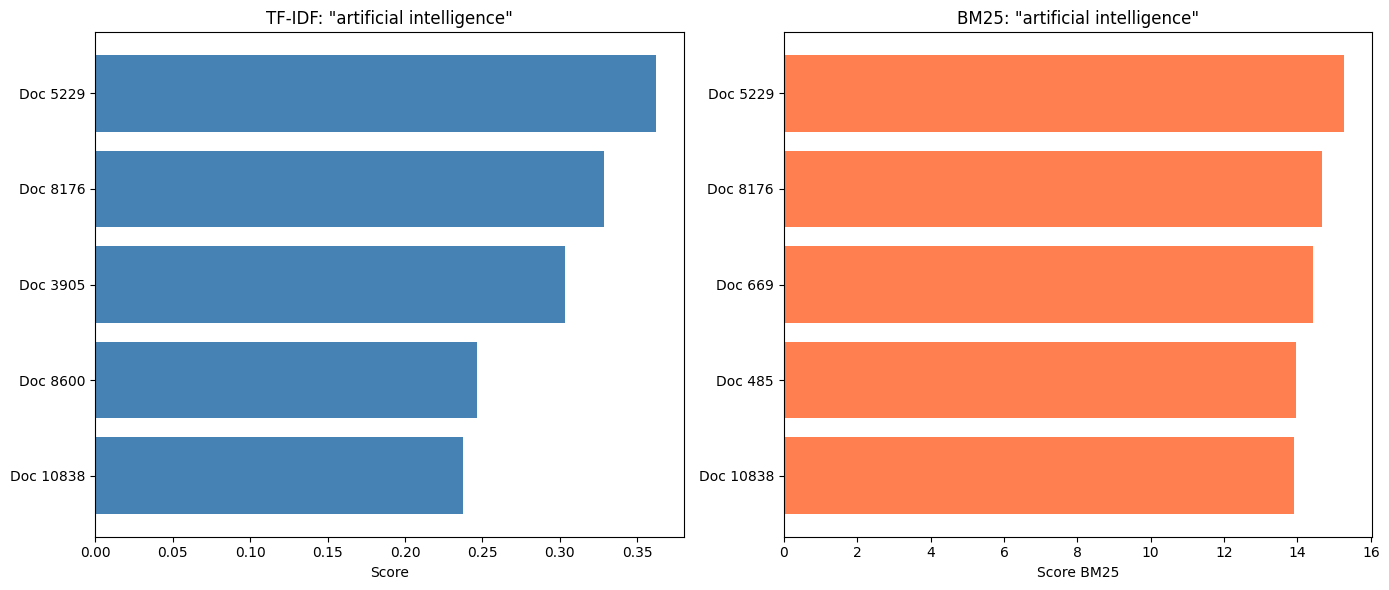


COMPARACIÓN: machine learning


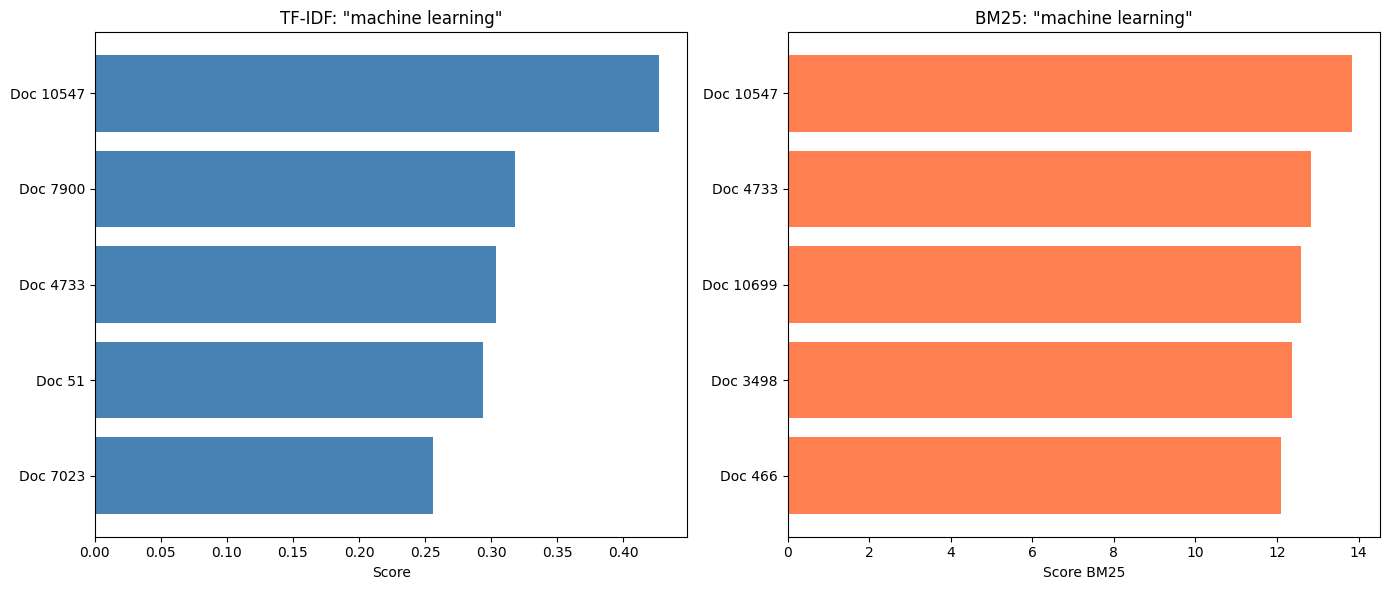


COMPARACIÓN: history of europe


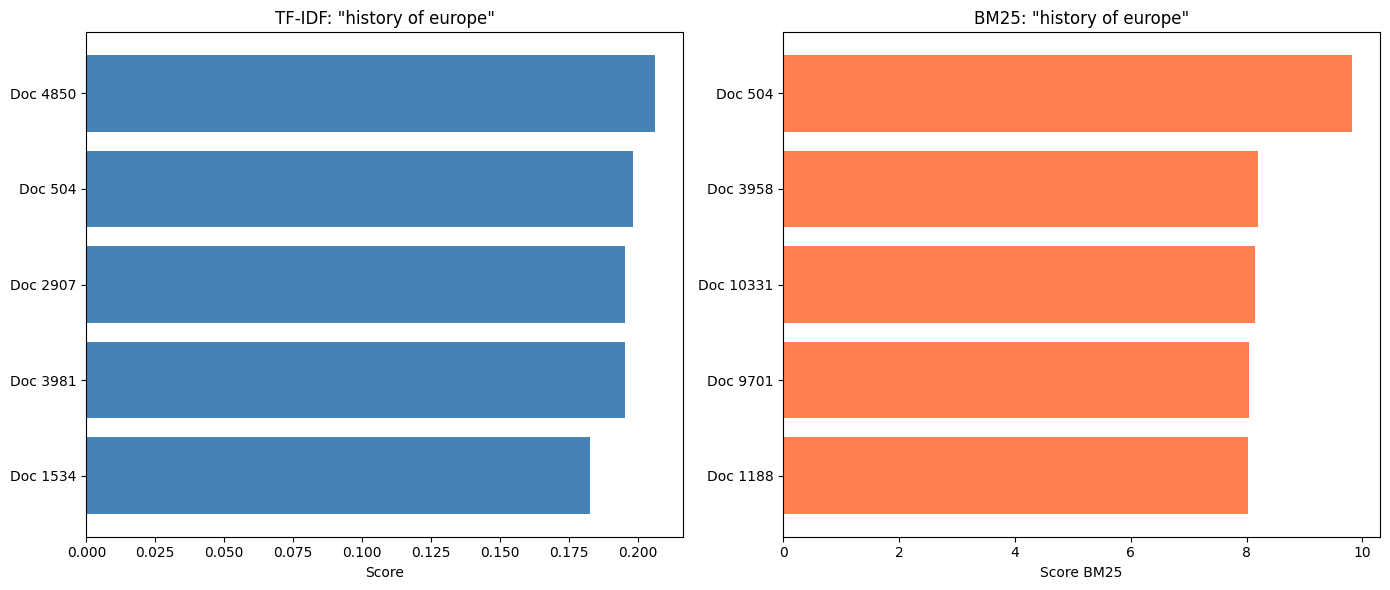


COMPARACIÓN: world war


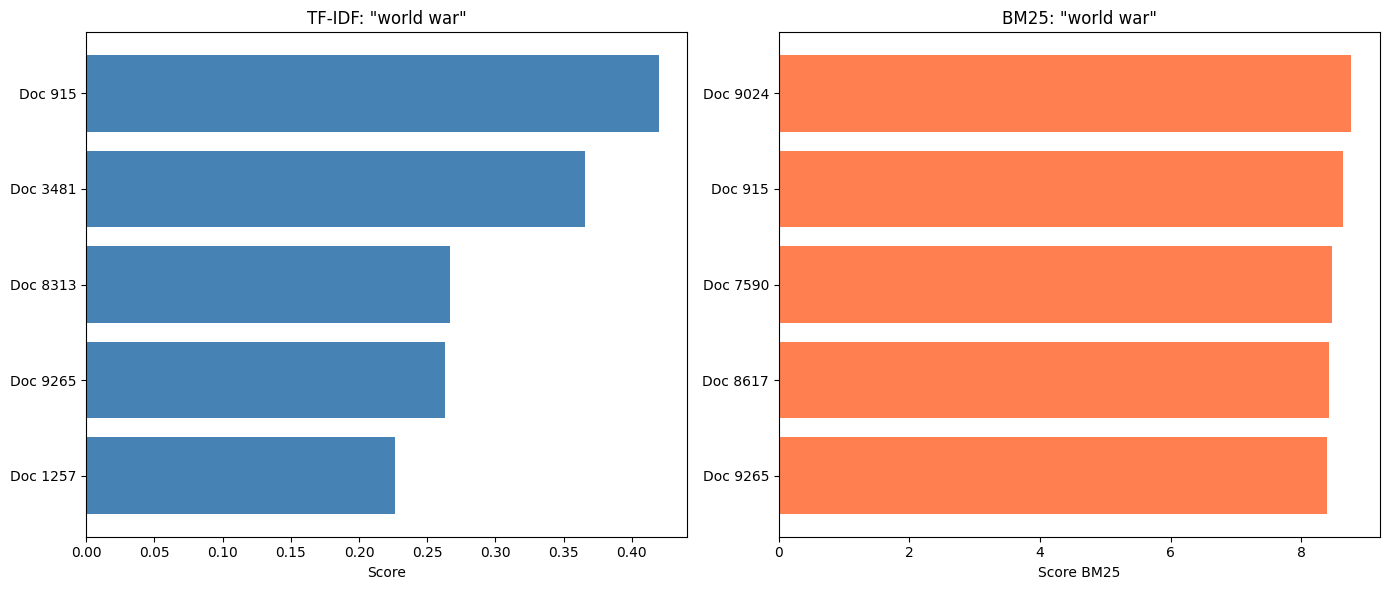


COMPARACIÓN: computer science


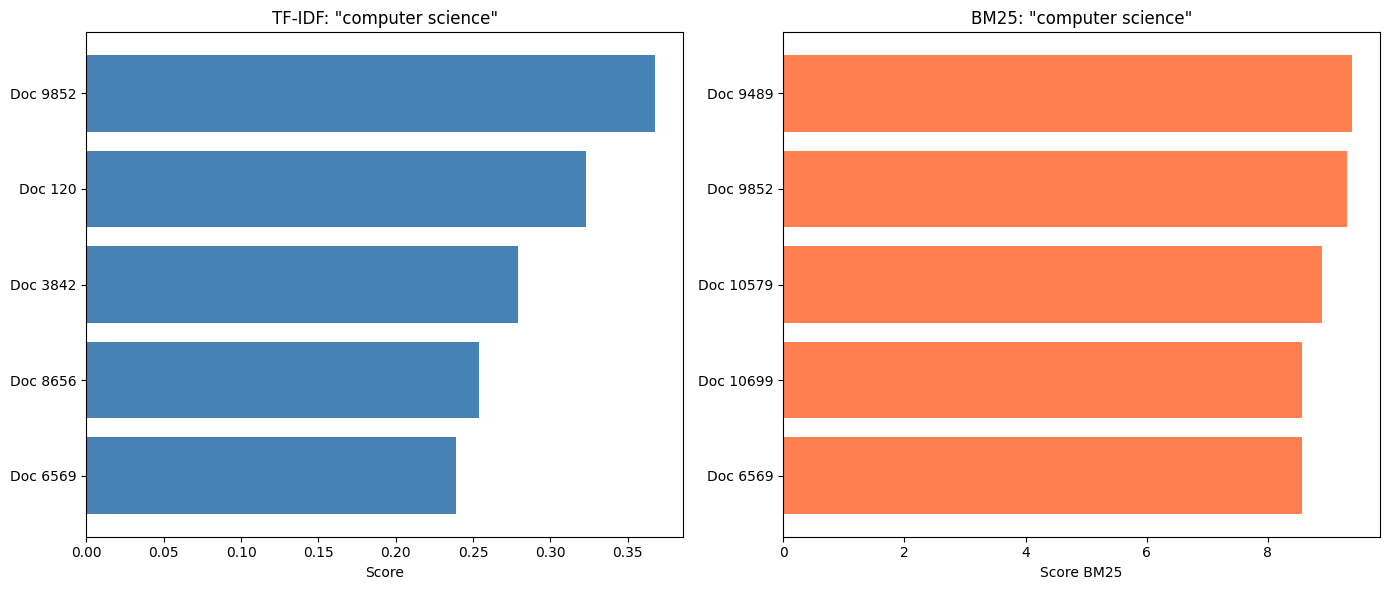


COMPARACIÓN: data analysis


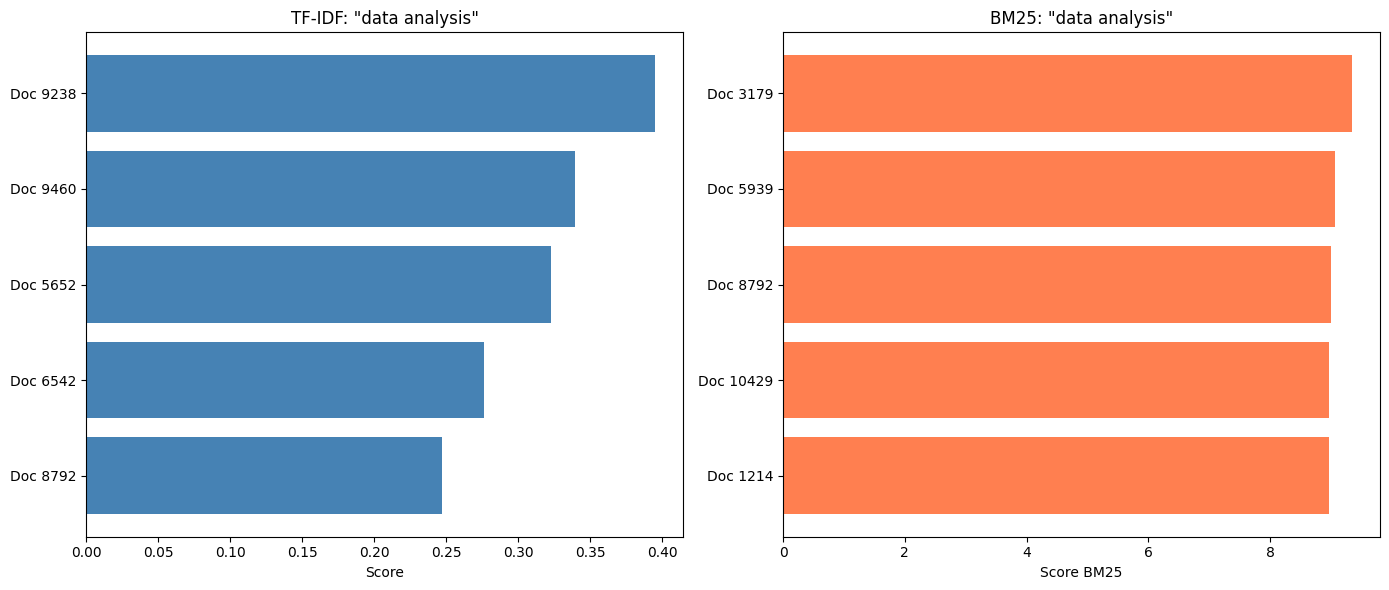


COMPARACIÓN: neural networks


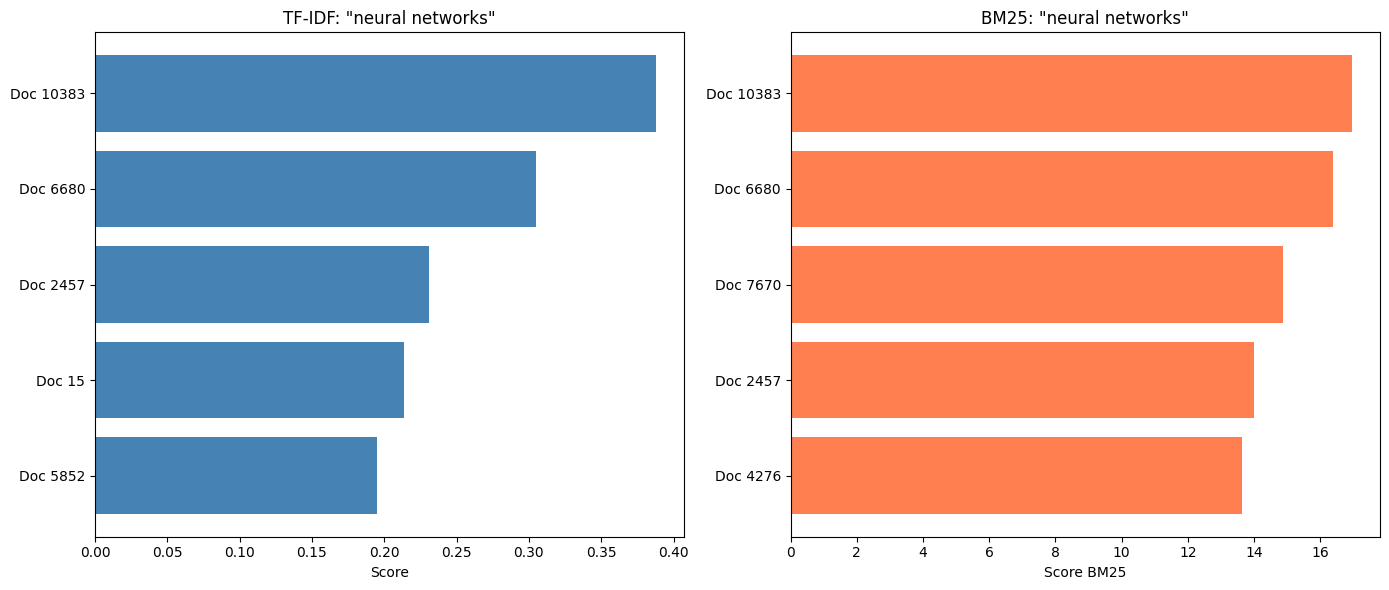


COMPARACIÓN: space exploration


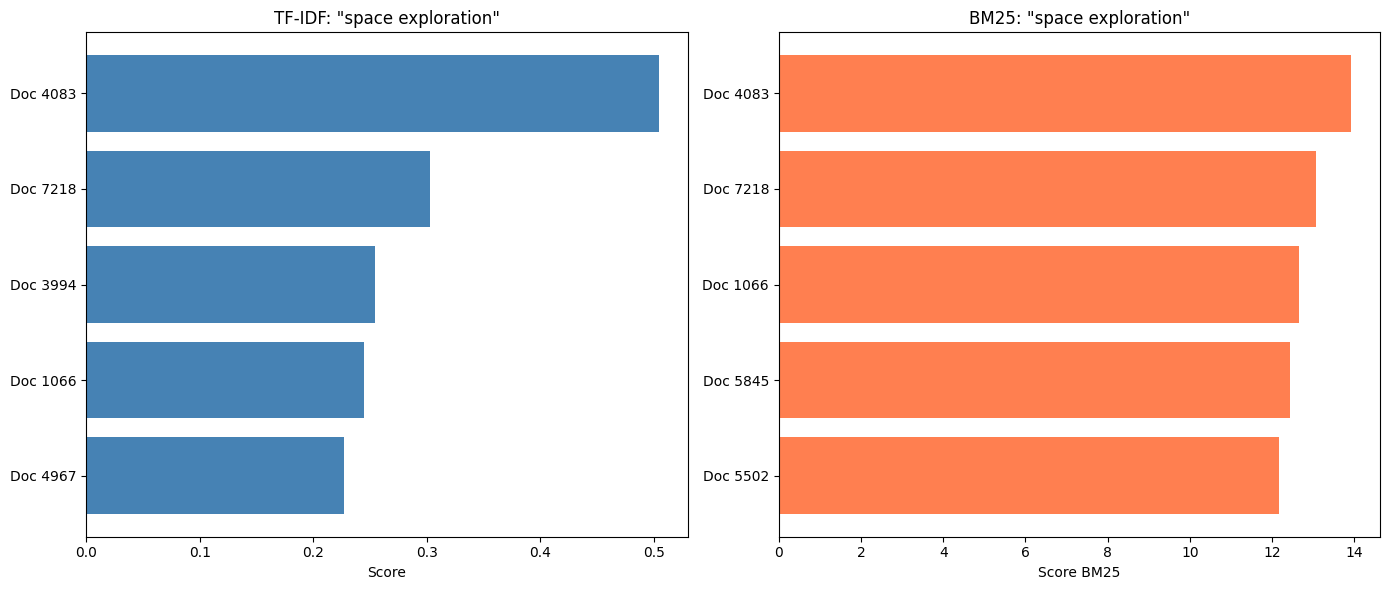


COMPARACIÓN: human biology


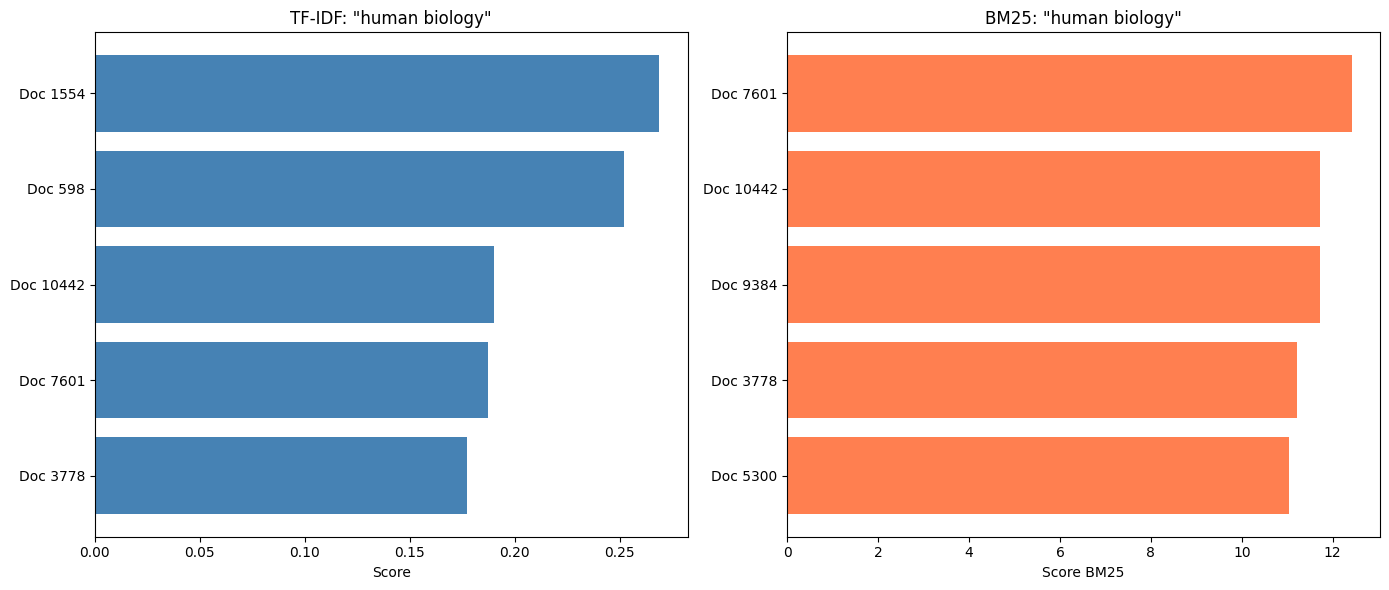


COMPARACIÓN: climate change


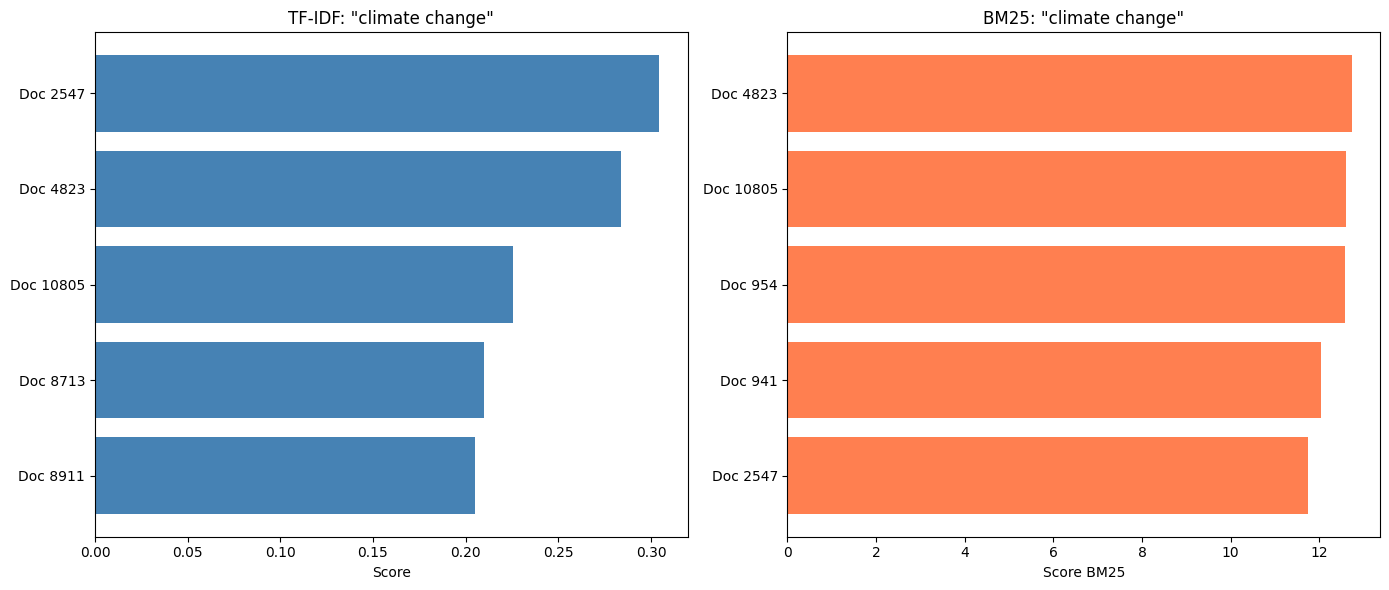

In [ ]:
import matplotlib.pyplot as plt

# Función para comparar TF-IDF y BM25 visualmente
def comparar_modelos(query, top_k=5):
    # Obtener resultados de ambos modelos
    results_tfidf = search_tfidf(query, top_k=top_k)
    # Obtener resultados de BM25
    results_bm25 = buscar_bm25(query, top_n=top_k)
    
    # Extraer índices y scores
    # Para TF-IDF
    tfidf_indices = [r['document_index'] for r in results_tfidf]
    # scores de TF-IDF
    tfidf_scores = [r['score'] for r in results_tfidf]
    
    # Para BM25
    bm25_indices = [idx for idx, score in results_bm25]
    # scores de BM25
    bm25_scores = [score for idx, score in results_bm25]
    
    # Crear figura con dos subgráficos
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Gráfico TF-IDF
    axes[0].barh(range(len(tfidf_scores)), tfidf_scores, color='steelblue')
    axes[0].set_yticks(range(len(tfidf_indices)))
    axes[0].set_yticklabels([f"Doc {idx}" for idx in tfidf_indices])
    axes[0].set_xlabel('Score')
    axes[0].set_title(f'TF-IDF: "{query}"')
    axes[0].invert_yaxis()
    
    # Gráfico BM25
    axes[1].barh(range(len(bm25_scores)), bm25_scores, color='coral')
    axes[1].set_yticks(range(len(bm25_indices)))
    axes[1].set_yticklabels([f"Doc {idx}" for idx in bm25_indices])
    axes[1].set_xlabel('Score BM25')
    axes[1].set_title(f'BM25: "{query}"')
    axes[1].invert_yaxis()
    
    plt.tight_layout()
    plt.show()
    
    return tfidf_indices, bm25_indices

# Comparar para cada query
for query in queries:
    print(f"\n{'='*60}")
    print(f"COMPARACIÓN: {query}")
    print('='*60)
    comparar_modelos(query, top_k=5)
